In [1]:
import os
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Load data from folder

In [2]:
data_path = '/kaggle/input/datasets/phnggiakhang/damaged-traffic-signs/sign_damage_v1_raw/train'

image_paths = []
labels = []

class_names = os.listdir(data_path)

for label in class_names:
    class_dir = os.path.join(data_path, label)
    for img in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img))
        labels.append(label)

class_names

['paint_loss',
 'normal',
 'bent',
 'rust',
 'broken_sheet',
 'graffiti',
 'scratch',
 'crack']

### Create a custom dataset class

In [3]:
class CustomDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        
        # consistent label encoding
        self.label_to_idx = {
            label: idx for idx, label in enumerate(sorted(set(labels)))
        }

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        # load image
        image = Image.open(img_path).convert("RGB")

        # apply transform
        if self.transform:
            image = self.transform(image)

        # encode label
        label = self.label_to_idx[label]

        return image, label

Train-test split

In [4]:
# Train-temp split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

# Val-test split from temp
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 1320
Validation: 283
Test: 283


### Calculate mean and standard deviation

In [5]:
# temp_train_transforms = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
# temp_train_dataset = CustomDataset(image_paths, labels, transform=temp_train_transforms)
# temp_train_loader = DataLoader(dataset=temp_train_dataset, batch_size=32, shuffle=False)

In [6]:
# def get_mean_and_std(loader):
#     channel_sum = 0.
#     channel_sum_sq = 0.
#     total_pixels = 0

#     for images, _ in loader:
#         # images: [B, C, H, W]
#         channel_sum += images.sum(dim=[0, 2, 3])
#         channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])
#         total_pixels += images.size(0) * images.size(2) * images.size(3)

#     mean = channel_sum / total_pixels
#     std = ((channel_sum_sq / total_pixels) - (mean ** 2)).sqrt()

#     return mean, std

In [7]:
# mean, std = get_mean_and_std(temp_train_loader)
# print('Mean:', mean)
# print('Standard deviation:', std)

### Data augmentation

In [8]:
# Mean and Std from ImageNet1K
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
        transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

### Create datasets and data loaders

In [9]:
train_dataset = CustomDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = CustomDataset(val_paths, val_labels, transform=val_transforms)
test_dataset = CustomDataset(test_paths, test_labels, transform=test_transforms)

In [10]:
# Defining data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

### EfficientNetV2 

In [11]:
# Load pretrained model and weights
weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

# Replace the classifier
num_classes = len(train_dataset.label_to_idx)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),

    nn.Dropout(p=0.3),
    nn.Linear(512,128),
    nn.BatchNorm1d(128),
    nn.ReLU(inplace=True),

    nn.Linear(128, num_classes)
)
model = model.to(device)

# Freeze the base for transfer learning
for param in model.features.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 213MB/s]


### Compute class weights for handling Class Imbalance

In [12]:
def compute_class_weights(labels, label_to_idx):
    counts = {label: 0 for label in label_to_idx}
    
    for label in labels:
        counts[label] += 1

    total = sum(counts.values())
    num_classes = len(counts)

    weights = []
    for label in sorted(label_to_idx, key=lambda x: label_to_idx[x]):
        count = counts[label]
        weight = total / (num_classes * count)
        weights.append(weight)

    return torch.tensor(weights, dtype=torch.float)

In [13]:
class_weights = compute_class_weights(train_labels, train_dataset.label_to_idx)
class_weights = class_weights.to(device)

### Transfer learning

In [14]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Reduce LR when validation stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',        
    factor=0.4,
    patience=3,
)

Training loop

In [15]:
# Early stopping config
early_stop_patience = 7
best_val_acc = 0.0
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

num_epochs = 40

In [16]:
# Record history for plotting
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_running_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Save history 
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Scheduler step
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save the model
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "EffnetV2_transfer.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    # Early stopping
    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered")
        break

print("Transfer learning EffNetV2 saved to /kaggle/working/EffnetV2_transfer.pth")

Epoch 1: Train Acc=0.1326, Val Acc=0.2403, Train Loss=2.0890, Val Loss=1.9710
Epoch 2: Train Acc=0.2727, Val Acc=0.4311, Train Loss=1.9477, Val Loss=1.8416
Epoch 3: Train Acc=0.3682, Val Acc=0.4947, Train Loss=1.8221, Val Loss=1.7599
Epoch 4: Train Acc=0.4083, Val Acc=0.5300, Train Loss=1.7452, Val Loss=1.6762
Epoch 5: Train Acc=0.4591, Val Acc=0.5512, Train Loss=1.6493, Val Loss=1.5947
Epoch 6: Train Acc=0.5212, Val Acc=0.5654, Train Loss=1.5211, Val Loss=1.5384
Epoch 7: Train Acc=0.5470, Val Acc=0.6113, Train Loss=1.4653, Val Loss=1.4763
Epoch 8: Train Acc=0.5591, Val Acc=0.6396, Train Loss=1.4099, Val Loss=1.4335
Epoch 9: Train Acc=0.5712, Val Acc=0.6572, Train Loss=1.4012, Val Loss=1.3598
Epoch 10: Train Acc=0.6030, Val Acc=0.6714, Train Loss=1.3193, Val Loss=1.3242
Epoch 11: Train Acc=0.6083, Val Acc=0.6926, Train Loss=1.2743, Val Loss=1.2879
Epoch 12: Train Acc=0.6242, Val Acc=0.7279, Train Loss=1.2024, Val Loss=1.2406
Epoch 13: Train Acc=0.6371, Val Acc=0.7385, Train Loss=1.1481

### Fine-tuning

Loading model weights

In [17]:
num_classes = len(train_dataset.label_to_idx)

model = efficientnet_v2_s(weights=None)

# match your custom classifier
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),

    nn.Dropout(p=0.3),
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(inplace=True),

    nn.Linear(128, num_classes)
)

# Load trained weights
model.load_state_dict(torch.load(
    "/kaggle/working/EffnetV2_transfer.pth"
))

model = model.to(device)

In [18]:
# Unfreeze for fine-tuning
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last few stages
for param in model.features[-2:].parameters():
    param.requires_grad = True

# Train the classifier
for param in model.classifier.parameters():
    param.requires_grad = True

In [19]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.4,
    patience=3,
)

In [20]:
# Fine-tune configurations
best_val_acc = 0.0
patience = 15
no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

num_epochs = 50

In [21]:
# Fine-tune loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)   
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()
    
    train_loss = running_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_running_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)  
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / val_total
    val_loss = val_running_loss / val_total

    # Save the history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Save the model
        torch.save(model.state_dict(), "/kaggle/working/EffnetV2_fine-tuned.pth")
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print("Early stopping")
        break

print("Fine-tuned EffNetV2 saved to /kaggle/working/EffnetV2_fine-tuned.pth")

Epoch 1: Train Acc=0.7129, Val Acc=0.7774, Train Loss=0.8024, Val Loss=0.8857
Epoch 2: Train Acc=0.7455, Val Acc=0.7951, Train Loss=0.7550, Val Loss=0.8841
Epoch 3: Train Acc=0.7515, Val Acc=0.7915, Train Loss=0.7141, Val Loss=0.8451
Epoch 4: Train Acc=0.7508, Val Acc=0.8021, Train Loss=0.6963, Val Loss=0.8502
Epoch 5: Train Acc=0.7553, Val Acc=0.7951, Train Loss=0.6781, Val Loss=0.8233
Epoch 6: Train Acc=0.7735, Val Acc=0.8057, Train Loss=0.6521, Val Loss=0.8224
Epoch 7: Train Acc=0.7727, Val Acc=0.8127, Train Loss=0.6327, Val Loss=0.8129
Epoch 8: Train Acc=0.7833, Val Acc=0.8092, Train Loss=0.6042, Val Loss=0.8054
Epoch 9: Train Acc=0.7909, Val Acc=0.8092, Train Loss=0.5934, Val Loss=0.8003
Epoch 10: Train Acc=0.7955, Val Acc=0.8163, Train Loss=0.5768, Val Loss=0.7859
Epoch 11: Train Acc=0.7909, Val Acc=0.8127, Train Loss=0.5690, Val Loss=0.7700
Epoch 12: Train Acc=0.7750, Val Acc=0.8198, Train Loss=0.5942, Val Loss=0.7866
Epoch 13: Train Acc=0.7992, Val Acc=0.8163, Train Loss=0.5637

### Training History

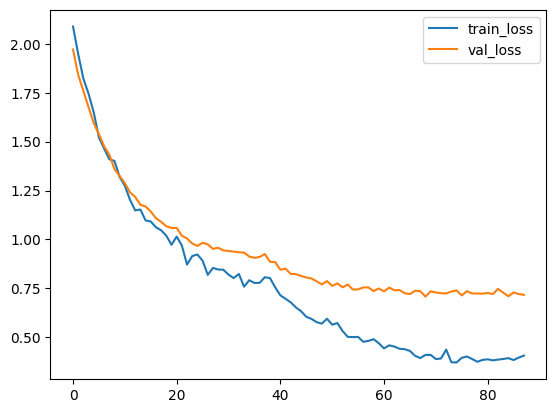

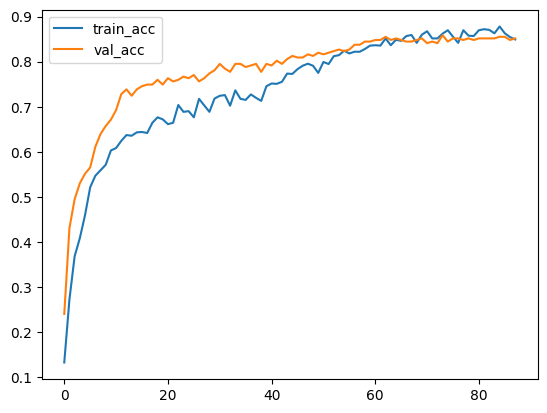

In [22]:
# Loss the training loss and accuracy
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()

### Evaluation


--- Classification Report ---
              precision    recall  f1-score   support

        bent     0.8400    0.7500    0.7925        28
broken_sheet     0.7143    0.7143    0.7143        14
       crack     0.6250    0.8333    0.7143        12
    graffiti     0.9846    0.9275    0.9552        69
      normal     0.8571    0.9438    0.8984        89
  paint_loss     1.0000    0.6250    0.7692         8
        rust     0.9500    0.8444    0.8941        45
     scratch     0.8500    0.9444    0.8947        18

    accuracy                         0.8799       283
   macro avg     0.8526    0.8229    0.8291       283
weighted avg     0.8880    0.8799    0.8803       283

Overall Accuracy: 0.8799
F1 Macro: 0.8291


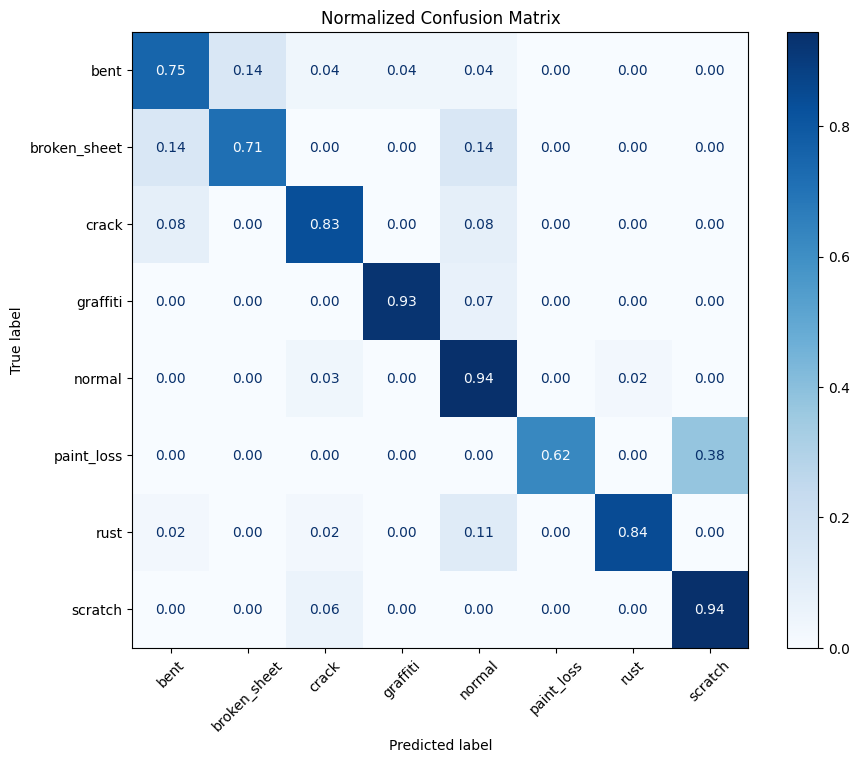

In [23]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# 1. Run evaluation
y_true, y_pred = evaluate_model(model, test_loader, device)
class_names = list(train_dataset.label_to_idx.keys())

# 2. Print Detailed Classification Report
# This includes Accuracy, Precision, Recall, and F1 for every class
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Individual Metrics (if you need them as variables)
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')

print(f"Overall Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")

# 4. Confusion Matrix (Enhanced)
# We use 'true' normalization to see percentages of correct hits per class
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap=plt.cm.Blues, ax=ax, values_format='.2f')

plt.title("Normalized Confusion Matrix")
plt.show()

### Stand-alone Inference Script

In [25]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_v2_s
from PIL import Image

# Class names in training order
CLASS_NAMES = [
    "bent",
    "broken_sheet",
    "crack",
    "graffiti",
    "normal",
    "paint_loss",
    "rust",
    "scratch"
]

# Rebuild the same model architecture EfficientNetV2_s
def build_model(num_classes):
    model = efficientnet_v2_s(weights=None)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),

        nn.Dropout(p=0.3),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),

        nn.Linear(128, num_classes)
    )

    return model

# Load model weights
def load_model(weight_path, device):
    model = build_model(len(CLASS_NAMES))
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.to(device)
    model.eval()
    return model

# Preprocessing
def get_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

# Inference function
def predict_image(image_path, model, device):
    transform = get_transform()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # shape: [1, 3, 224, 224]

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

    predicted_class = CLASS_NAMES[pred.item()]
    confidence = conf.item()

    return predicted_class, confidence

# Example use case
if __name__ == "__main__":
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    MODEL_PATH = "/kaggle/working/EffnetV2_fine-tuned.pth"
    IMAGE_PATH = "/kaggle/input/datasets/phnggiakhang/test-sign-scratch/new_deh_county_update_sign_pic_web.max-640x480.jpg"

    model = load_model(MODEL_PATH, DEVICE)

    pred_class, conf = predict_image(IMAGE_PATH, model, DEVICE)

    print(f"Prediction: {pred_class}")
    print(f"Confidence: {conf:.4f}")

Prediction: rust
Confidence: 0.4854
